In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.ticker as mtick
from scipy import stats

In [ ]:
# Đọc dữ liệu
path = Path('/content/drive/MyDrive/Datathon_VinTelligence/data/data_clean')
name  = 'Dataset_3_Operations_Logistics.csv' # Added .csv extension
finalpath = path/name
df = pd.read_csv(finalpath)
df.head()

,order_id,ship_date,delivery_date,shipping_fee,delivery_time_days,return_flag,total_quantity,stock_on_hand_avg,stockout_days_max,fill_rate_avg,stockout_flag_max
0,1,2012-07-07,2012-07-11,1.37,4,0,7,236.0,2.0,0.9333,1.0
1,2,2012-07-06,2012-07-10,2.60,4,1,7,236.0,2.0,0.9333,1.0
2,3,2012-07-04,2012-07-07,2.38,3,0,3,319.0,1.0,0.9667,1.0
3,4,2012-07-05,2012-07-11,2.49,6,0,5,327.0,0.0,1.0000,0.0
4,6,2012-07-09,2012-07-16,25.79,7,0,1,102.0,0.0,1.0000,0.0


# Operations & Logistics – Exploratory Data Analysis (EDA)
*Chi tiết các chỉ số giao hàng, tồn kho và rủi ro dịch vụ.*

In [ ]:
# Tiền xử lý
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df['delivery_time_days'] = (df['delivery_date'] - df['ship_date']).dt.days
df['month_year'] = df['ship_date'].dt.to_period('M').astype(str)

# Theme
sns.set(style='whitegrid', rc={'figure.figsize':(12,6)})
custom_palette = sns.color_palette('viridis', 10)
sns.set_palette(custom_palette)

## 1️⃣ Hiệu suất Giao hàng (Delivery Performance)
*Lead time và phí vận chuyển.*

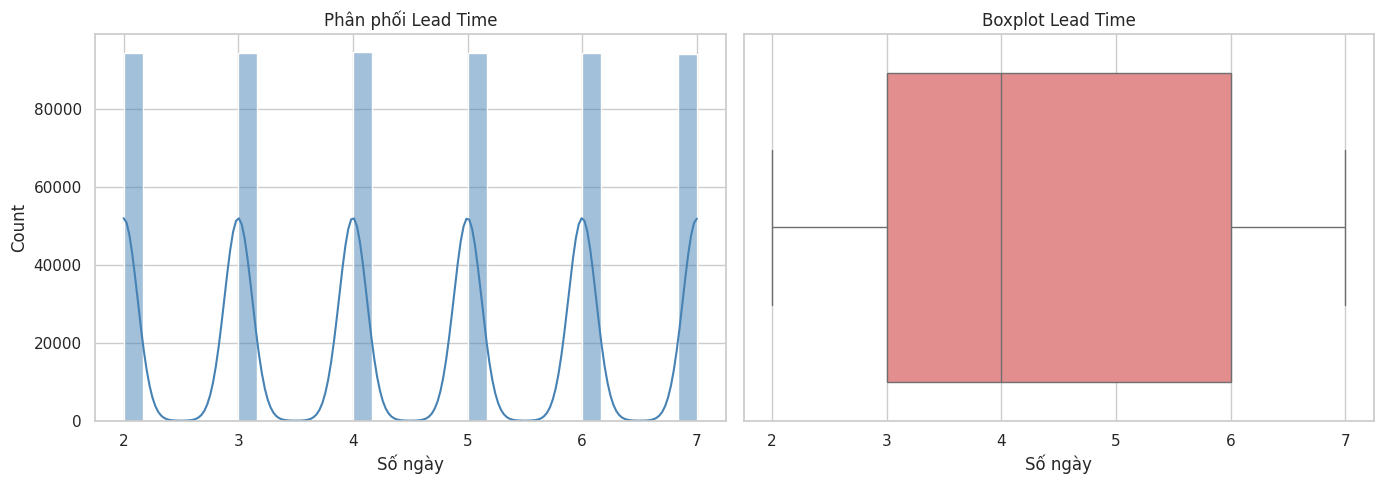

In [ ]:
# Lead Time distribution (hist + KDE + box)
fig, ax = plt.subplots(1,2,figsize=(14,5))
sns.histplot(df['delivery_time_days'], bins=30, kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('Phân phối Lead Time')
ax[0].set_xlabel('Số ngày')
sns.boxplot(x=df['delivery_time_days'], ax=ax[1], color='lightcoral')
ax[1].set_title('Boxplot Lead Time')
ax[1].set_xlabel('Số ngày')
plt.tight_layout()
plt.show()

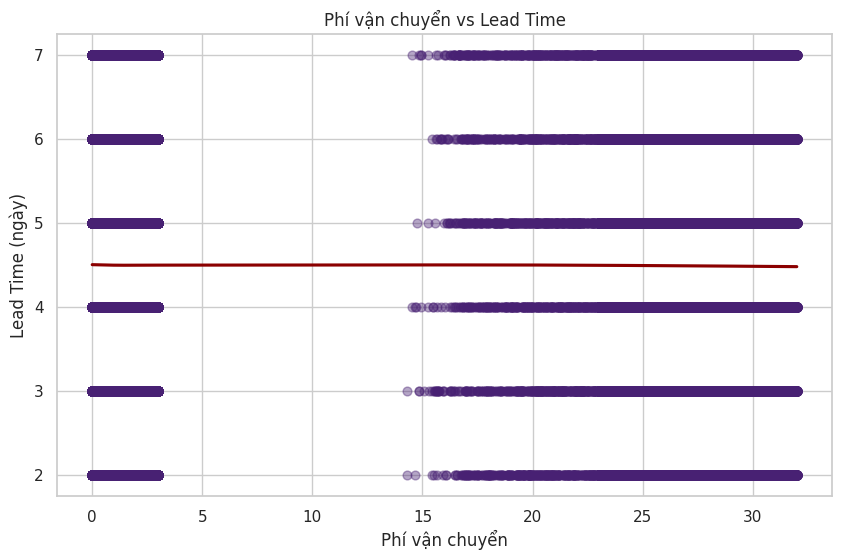

In [ ]:
# Shipping fee vs Lead Time (scatter + LOWESS)
plt.figure(figsize=(10,6))
sns.regplot(data=df, x='shipping_fee', y='delivery_time_days', scatter_kws={'alpha':0.4,'s':40}, lowess=True, line_kws={'color':'darkred'})
plt.title('Phí vận chuyển vs Lead Time')
plt.xlabel('Phí vận chuyển')
plt.ylabel('Lead Time (ngày)')
plt.show()

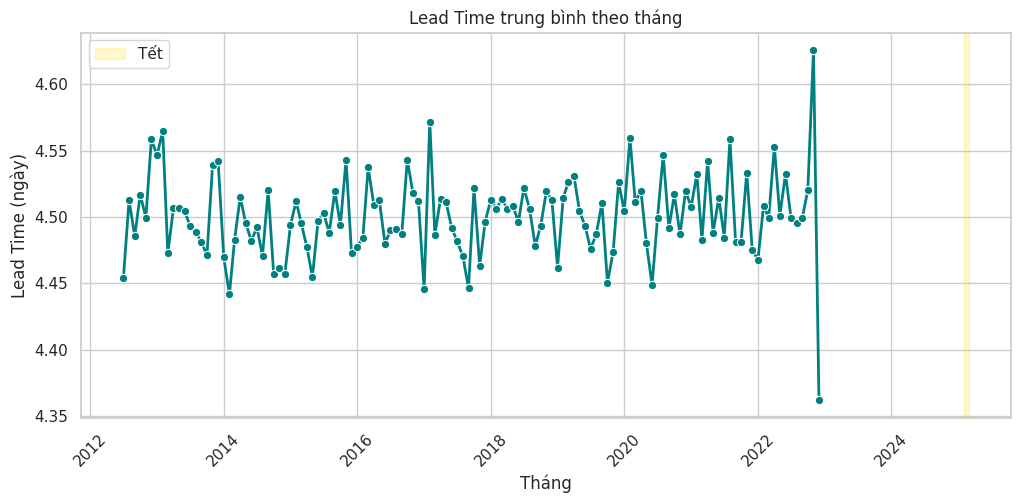

In [ ]:
# Lead Time theo tháng (line + holiday shading)
monthly = df.groupby('month_year')['delivery_time_days'].mean().reset_index()
monthly['month_dt'] = pd.to_datetime(monthly['month_year'])
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='month_dt', y='delivery_time_days', marker='o', linewidth=2, color='teal')
# Ví dụ: Tết năm 2025 (tháng 02/2025)
plt.axvspan(pd.Timestamp('2025-02-01'), pd.Timestamp('2025-02-28'), color='gold', alpha=0.2, label='Tết')
plt.title('Lead Time trung bình theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Lead Time (ngày)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

## 2️⃣ Hiệu quả Kho bãi & Khả năng Đáp ứng (Inventory & Fulfillment)
*Tồn kho, ngày hết hàng và Fill Rate.*

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


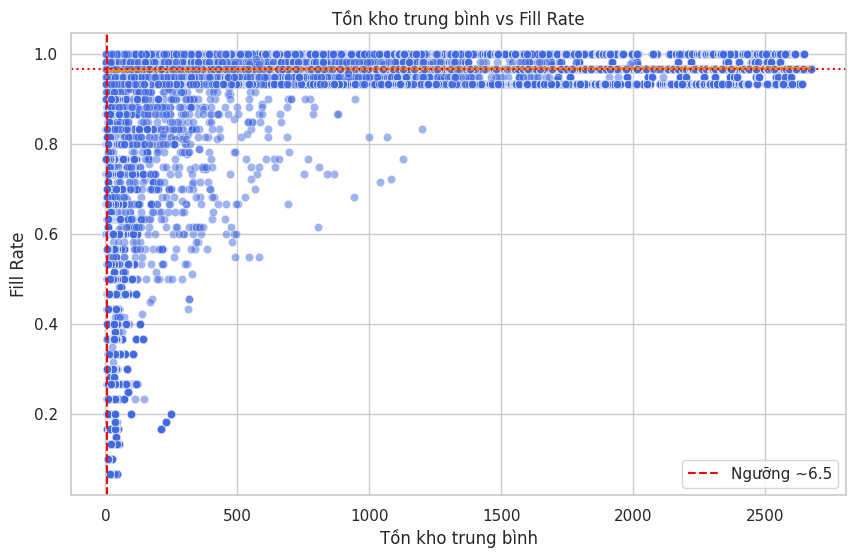

In [ ]:
# 2.1 Stock on Hand vs Fill Rate – Scatter + LOWESS + Threshold annotation
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='stock_on_hand_avg', y='fill_rate_avg', alpha=0.5, color='royalblue')
# LOWESS smoothing
lowess = sns.regplot(data=df, x='stock_on_hand_avg', y='fill_rate_avg', lowess=True, scatter=False, color='darkorange', line_kws={'linewidth':2})
# Tính điểm ngưỡng (đầu điểm mà tăng thêm tồn kho < 0.3% fill rate)
sorted_df = df.sort_values('stock_on_hand_avg')
diff = sorted_df['fill_rate_avg'].diff() / sorted_df['stock_on_hand_avg'].diff()
threshold_idx = (diff.abs() < 0.003).idxmax()
if pd.notna(threshold_idx):
    thr_stock = sorted_df.loc[threshold_idx, 'stock_on_hand_avg']
    thr_fill = sorted_df.loc[threshold_idx, 'fill_rate_avg']
    plt.axvline(thr_stock, color='red', linestyle='--', label=f'Ngưỡng ~{thr_stock:.1f}')
    plt.axhline(thr_fill, color='red', linestyle=':')

plt.title('Tồn kho trung bình vs Fill Rate')
plt.xlabel('Tồn kho trung bình')
plt.ylabel('Fill Rate')
plt.legend()
plt.show()

/tmp/ipykernel_510/2796864684.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby('stockout_bin')['fill_rate_avg'].agg(['mean','std','count']).reset_index()
/tmp/ipykernel_510/2796864684.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(data=agg, x='stockout_bin', y='mean', join=True, capsize=.2, color='mediumseagreen')


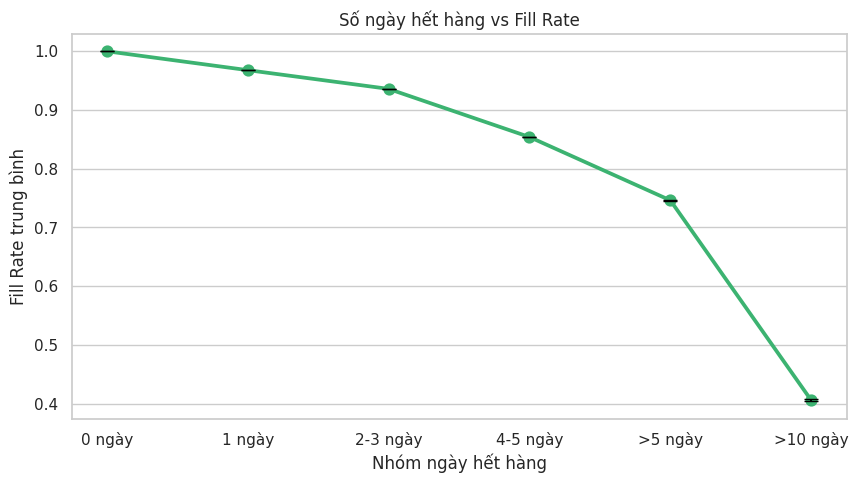

In [ ]:
# 2.2 Stockout Days vs Fill Rate – Binned line plot with confidence interval
df['stockout_bin'] = pd.cut(df['stockout_days_max'], bins=[-1,0,1,3,5,10, np.inf], labels=['0 ngày','1 ngày','2-3 ngày','4-5 ngày','>5 ngày','>10 ngày'])
agg = df.groupby('stockout_bin')['fill_rate_avg'].agg(['mean','std','count']).reset_index()
agg['sem'] = agg['std']/np.sqrt(agg['count'])
plt.figure(figsize=(10,5))
sns.pointplot(data=agg, x='stockout_bin', y='mean', join=True, capsize=.2, color='mediumseagreen')
plt.errorbar(x=range(len(agg)), y=agg['mean'], yerr=agg['sem'], fmt='none', c='black', capsize=5)
plt.title('Số ngày hết hàng vs Fill Rate')
plt.xlabel('Nhóm ngày hết hàng')
plt.ylabel('Fill Rate trung bình')
plt.show()

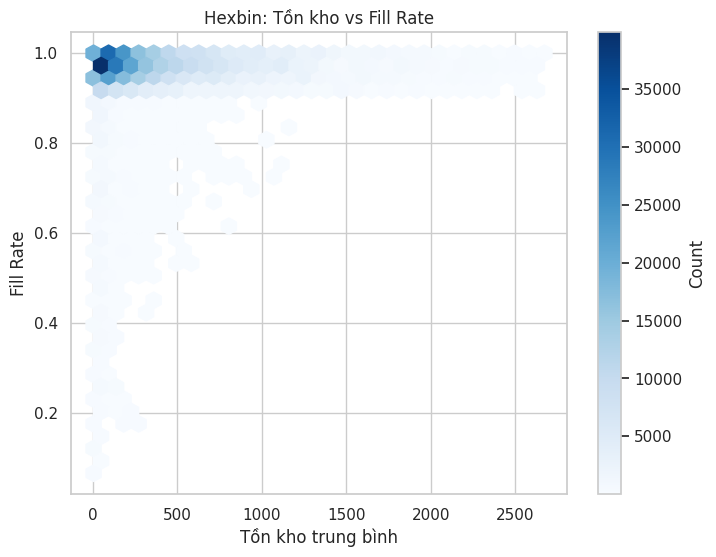

In [ ]:
# 2.3 Heatmap của quan hệ 2D (hexbin) – Stock vs Fill Rate
plt.figure(figsize=(8,6))
hb = plt.hexbin(df['stock_on_hand_avg'], df['fill_rate_avg'], gridsize=30, cmap='Blues', mincnt=1)
plt.colorbar(hb, label='Count')
plt.title('Hexbin: Tồn kho vs Fill Rate')
plt.xlabel('Tồn kho trung bình')
plt.ylabel('Fill Rate')
plt.show()

## 3️⃣ Chất lượng Dịch vụ & Rủi ro (Service Quality & Risk)
*Liên quan đến thời gian giao hàng, trả hàng và tình trạng hết hàng.*

/tmp/ipykernel_510/991171387.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='lt_bucket', y='return_flag', inner='quartile', palette='OrRd')


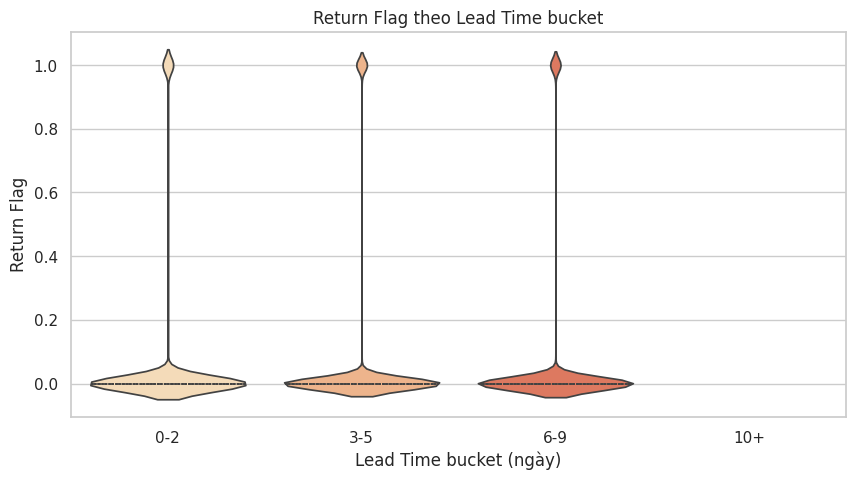

In [ ]:
# 3.1 Delivery Time vs Return Flag – Violin per Lead Time bucket
# Tạo bucket cho Lead Time (0‑2,3‑5,6‑9,10+ ngày)
df['lt_bucket'] = pd.cut(df['delivery_time_days'], bins=[-1,2,5,9, np.inf], labels=['0‑2','3‑5','6‑9','10+'])
plt.figure(figsize=(10,5))
sns.violinplot(data=df, x='lt_bucket', y='return_flag', inner='quartile', palette='OrRd')
plt.title('Return Flag theo Lead Time bucket')
plt.xlabel('Lead Time bucket (ngày)')
plt.ylabel('Return Flag')
plt.show()

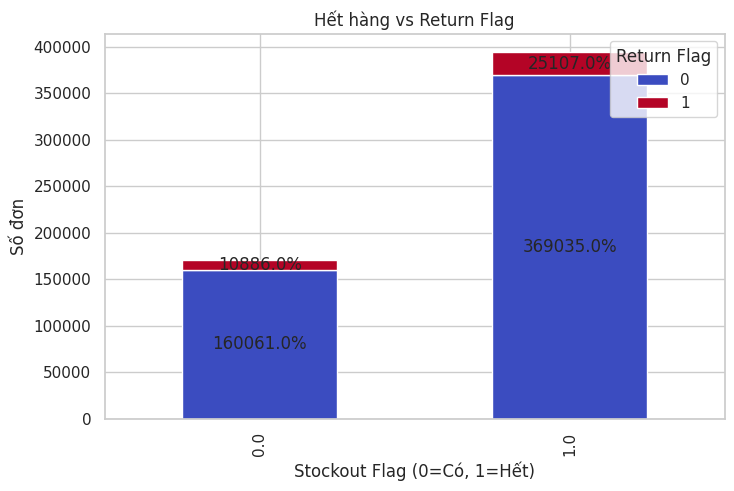

In [ ]:
# 3.2 Stockout Flag vs Return Flag – Stacked bar + percentage annotation
stock_ret = df.groupby(['stockout_flag_max','return_flag']).size().unstack(fill_value=0)
stock_ret_pct = stock_ret.div(stock_ret.sum(axis=1), axis=0)
ax = stock_ret.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(8,5))
plt.title('Hết hàng vs Return Flag')
plt.xlabel('Stockout Flag (0=Có, 1=Hết)')
plt.ylabel('Số đơn')
# Annotate percentages on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.legend(title='Return Flag', loc='upper right')
plt.show()

## 4️⃣ Ma trận tương quan chi tiết (Correlation Matrices)
*Hai ma trận: một cho các biến kho bãi, một cho các biến dịch vụ.*

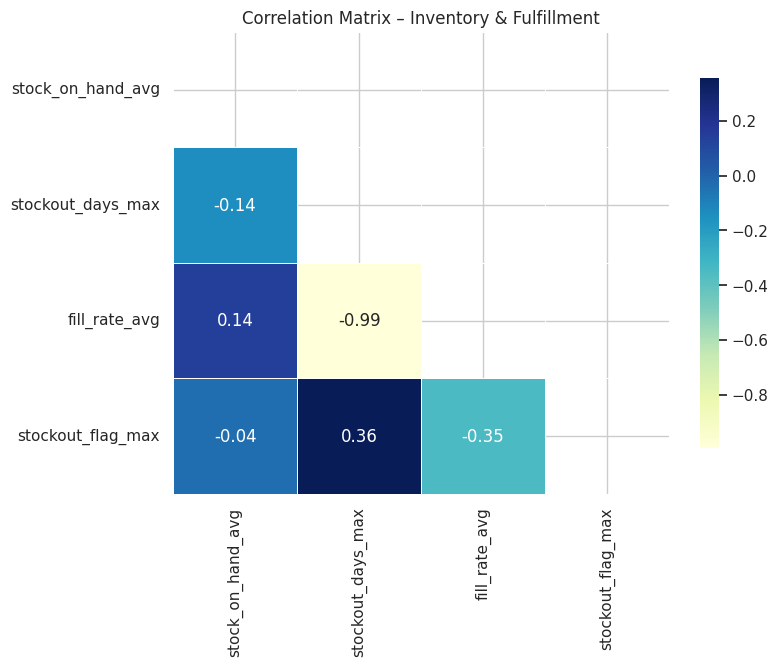

In [ ]:
# 4.1 Correlation Matrix – Inventory related
inv_cols = ['stock_on_hand_avg','stockout_days_max','fill_rate_avg','stockout_flag_max']
corr_inv = df[inv_cols].corr()
mask = np.triu(np.ones_like(corr_inv, dtype=bool))
plt.figure(figsize=(8,6))
sns.heatmap(corr_inv, mask=mask, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=.5, cbar_kws={'shrink':0.8})
plt.title('Correlation Matrix – Inventory & Fulfillment')
plt.show()

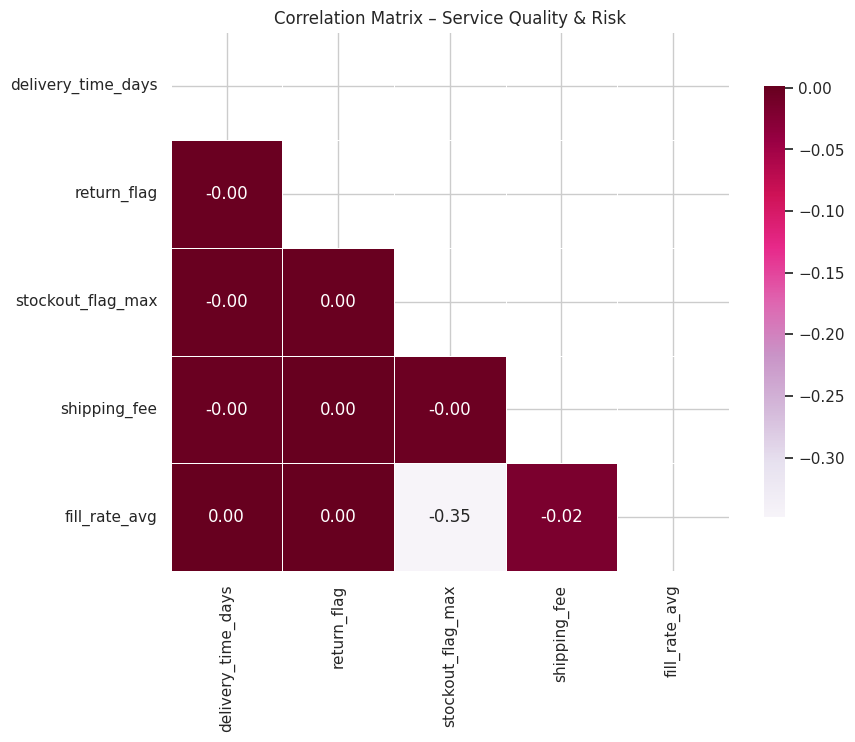

In [ ]:
# 4.2 Correlation Matrix – Service Quality & Risk
svc_cols = ['delivery_time_days','return_flag','stockout_flag_max','shipping_fee','fill_rate_avg']
corr_svc = df[svc_cols].corr()
mask = np.triu(np.ones_like(corr_svc, dtype=bool))
plt.figure(figsize=(9,7))
sns.heatmap(corr_svc, mask=mask, annot=True, fmt='.2f', cmap='PuRd', linewidths=.5, cbar_kws={'shrink':0.8})
plt.title('Correlation Matrix – Service Quality & Risk')
plt.show()